In [3]:
text = "John likes to watch movies. Mary likes movies too.\
 Mary also likes to watch football games."
words = text.replace('.', '').split()
words

['John',
 'likes',
 'to',
 'watch',
 'movies',
 'Mary',
 'likes',
 'movies',
 'too',
 'Mary',
 'also',
 'likes',
 'to',
 'watch',
 'football',
 'games']

In [4]:
import numpy as np
word_count = np.unique(words, return_counts=True)
word_count

(array(['John', 'Mary', 'also', 'football', 'games', 'likes', 'movies',
        'to', 'too', 'watch'], dtype='<U8'),
 array([1, 2, 1, 1, 1, 3, 2, 2, 1, 2]))

In [5]:
#딕셔너리 TF 생성
word_to_cnt = {}
for word, cnt in zip(*word_count):
  word_to_cnt[word] = cnt
  
word_to_cnt

{'John': 1,
 'Mary': 2,
 'also': 1,
 'football': 1,
 'games': 1,
 'likes': 3,
 'movies': 2,
 'to': 2,
 'too': 1,
 'watch': 2}

In [6]:
word_to_cnt['movies']

2

In [7]:
corpus = [
    "John likes to watch movies. Mary likes movies too.",
    "Mary also likes to watch football games."
]

In [8]:
from sklearn.feature_extraction.text import CountVectorizer
vector = CountVectorizer()
dtm_array = vector.fit_transform(corpus).toarray()
dtm_array

array([[0, 0, 0, 1, 2, 1, 2, 1, 1, 1],
       [1, 1, 1, 0, 1, 1, 0, 1, 0, 1]])

In [9]:
tf_dic = vector.vocabulary_
print(vector.vocabulary_)

{'john': 3, 'likes': 4, 'to': 7, 'watch': 9, 'movies': 6, 'mary': 5, 'too': 8, 'also': 0, 'football': 1, 'games': 2}


In [10]:
import pandas as pd
tf_dic_sorted = dict(sorted(tf_dic.items(), key=lambda item: item[1]))
#tf_dic_sorted
df = pd.DataFrame(dtm_array, columns=tf_dic_sorted.keys())
df

,also,football,games,john,likes,mary,movies,to,too,watch
0,0,0,0,1,2,1,2,1,1,1
1,1,1,1,0,1,1,0,1,0,1


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vec = TfidfVectorizer()
tfidf_array = tfidf_vec.fit_transform(corpus).toarray()
#tfidf_array

In [12]:
tfidf_dic = tfidf_vec.vocabulary_
#tfidf_dic
tfidf_dic_sorted = dict(sorted(tfidf_dic.items(), key=lambda item: item[1]))
tfidf_dtm = pd.DataFrame(tfidf_array, columns=tfidf_dic_sorted.keys())
tfidf_dtm

,also,football,games,john,likes,mary,movies,to,too,watch
0,0.000000,0.000000,0.000000,0.323699,0.460629,0.230315,0.647398,0.230315,0.323699,0.230315
1,0.446101,0.446101,0.446101,0.000000,0.317404,0.317404,0.000000,0.317404,0.000000,0.317404


In [13]:
# Word2Vec - gensim library

In [14]:
!pip install --upgrade gensim

In [15]:
!pip install "scipy<1.11"

In [16]:
from gensim.models import Word2Vec
corpus = [
    "John likes to watch movies. Mary likes movies too.",
    "Mary also likes to watch football games."
]
word_list = []

In [17]:
for word in corpus:
  word_list.append(word.replace('.','').split())
  
word_list

[['John', 'likes', 'to', 'watch', 'movies', 'Mary', 'likes', 'movies', 'too'],
 ['Mary', 'also', 'likes', 'to', 'watch', 'football', 'games']]

In [18]:
model = Word2Vec(word_list, sg=0, vector_size=100, window=3, min_count=1)
model.wv.most_similar('likes', 'movies')

[('John', 0.17164471745491028),
 ('also', 0.06594578176736832),
 ('Mary', 0.008838453330099583),
 ('watch', -0.06765829026699066),
 ('games', -0.08544928580522537),
 ('football', -0.08948154747486115),
 ('too', -0.11860241740942001),
 ('to', -0.13643866777420044)]

In [19]:

model = Word2Vec(word_list, sg=1, vector_size=100, window=3, min_count=1)
model.wv.most_similar('likes', 'movies')

[('John', 0.17164471745491028),
 ('also', 0.06594578176736832),
 ('Mary', 0.008853347972035408),
 ('watch', -0.06765829026699066),
 ('games', -0.08544928580522537),
 ('football', -0.08948154747486115),
 ('too', -0.11860241740942001),
 ('to', -0.13643862307071686)]

In [20]:
model = Word2Vec(word_list, sg=1, vector_size=100, window=3, min_count=1)
model.wv.most_similar('games')

[('to', 0.13887979090213776),
 ('watch', 0.13149002194404602),
 ('movies', 0.06408978253602982),
 ('too', 0.06059185042977333),
 ('football', 0.019152285531163216),
 ('Mary', 0.009383062832057476),
 ('also', -0.05774582177400589),
 ('likes', -0.05987628549337387),
 ('John', -0.10513809323310852)]

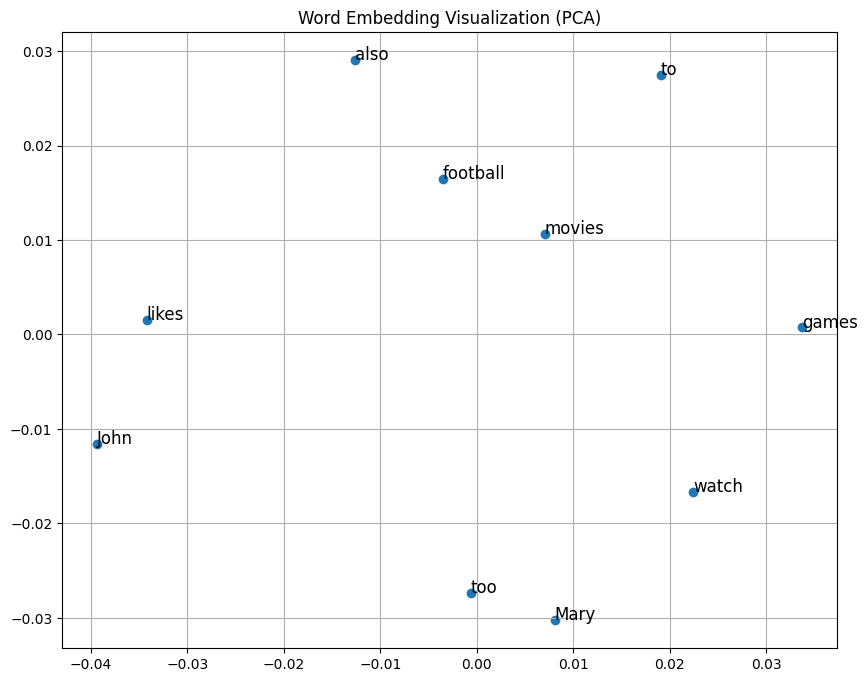

In [21]:
# 전체 단어 임베딩 시각화 (PCA/t-SNE)
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def visualize_embeddings(model):
    # 단어와 벡터 추출
    words = list(model.wv.index_to_key)
    vectors = model.wv[words]

# 100차원 -> 2차원 압축
    pca = PCA(n_components=2)
    result = pca.fit_transform(vectors)

# 시각화
    plt.figure(figsize=(10, 8))
    plt.scatter(result[:, 0], result[:, 1])

    for i, word in enumerate(words):
        plt.annotate(word, xy=(result[i, 0], result[i, 1]), fontsize=12)

    plt.title("Word Embedding Visualization (PCA)")
    plt.grid(True)
    plt.show()

visualize_embeddings(model)

In [24]:
import gensim.downloader as api

# 사용 가능한 데이터셋 확인
print(list(api.info()['corpora'].keys()))

# text8 다운로드 (영어 Wikipedia 일부, 약 85000문장)
dataset = api.load("text8")

from gensim.models import Word2Vec
model = Word2Vec(sentences=dataset, vector_size=100, window=5, min_count=5, sg=1)

model.wv.most_similar('king')
# 결과: [('queen', 0.7...), ('prince', 0.6...), ...] 같은 의미있는 결과 나옴

['semeval-2016-2017-task3-subtaskBC', 'semeval-2016-2017-task3-subtaskA-unannotated', 'patent-2017', 'quora-duplicate-questions', 'wiki-english-20171001', 'text8', 'fake-news', '20-newsgroups', '__testing_matrix-synopsis', '__testing_multipart-matrix-synopsis']
[==================================================] 100.0% 31.6/31.6MB downloaded


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

[('haakon', 0.7542034387588501),
 ('prince', 0.7525647282600403),
 ('canute', 0.744115948677063),
 ('valdemar', 0.7329500317573547),
 ('kings', 0.7318722009658813),
 ('queen', 0.7197225093841553),
 ('ethelred', 0.7174660563468933),
 ('sigismund', 0.7158119082450867),
 ('pretender', 0.7138211131095886),
 ('throne', 0.713025689125061)]